In [1]:
import flax
from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from simple_transformer.config import local_training_config, small_model_config
from simple_transformer.data import make_train_val_loaders
from simple_transformer.jax.model import JaxSimpleTransformerLM, count_parameters
from simple_transformer.jax.train import fit_jax

In [5]:
print(f"JAX version: {jax.__version__}")
print(f"Flax version: {flax.__version__}")
print(f"backend: {jax.default_backend()}")
print(f"devices: {jax.devices()}")

JAX version: 0.10.2
Flax version: 0.12.8
backend: cpu
devices: [CpuDevice(id=0)]


In [6]:
custom_examples = [
    "0+0=",
    "5+7=",
    "45-54=",
    "99-1=",
    "12*3=",
    "9*9=",
    "20/4=",
    "9/2=",
    "123+456=",
    "745-84=",
    "11*11=",
    "100/3=",
    "999+1=",
    "999-100=",
    "99*12=",
    "999/7=",
]

for example in custom_examples:
    print(example)

0+0=
5+7=
45-54=
99-1=
12*3=
9*9=
20/4=
9/2=
123+456=
745-84=
11*11=
100/3=
999+1=
999-100=
99*12=
999/7=


## Current JAX scope

The JAX backend currently supports model construction, training, and validation. Autoregressive generation, KV caching, checkpointing, TensorBoard integration, quantization, and latency benchmarks remain in the PyTorch experiment for now.

In [7]:
train_config = local_training_config(max_digits=3)
model_config = small_model_config(max_digits=train_config.max_digits)

model = JaxSimpleTransformerLM(
    model_config,
    rngs=nnx.Rngs(
        params=train_config.seed,
        dropout=train_config.seed + 1,
    ),
)
train_loader, val_loader, tokenizer = make_train_val_loaders(train_config)

# Run one deterministic forward pass to validate array shapes before training.
sample_batch = next(iter(train_loader))
sample_input_ids = jnp.asarray(sample_batch["input_ids"].numpy())
model.eval()
sample_logits = model(sample_input_ids)

print(f"parameters: {count_parameters(model):,}")
print(f"train batches: {len(train_loader)}, validation batches: {len(val_loader)}")
print(f"input shape: {sample_input_ids.shape}")
print(f"logits shape: {sample_logits.shape}")

parameters: 1,576,704
train batches: 512, validation batches: 64
input shape: (64, 14)
logits shape: (64, 14, 17)


In [8]:
def print_epoch(epoch, train, validation):
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train.loss:.4f} acc {train.accuracy:.3f} | "
        f"val loss {validation.loss:.4f} acc {validation.accuracy:.3f} | "
        f"lr {train.learning_rate:.2e}"
    )


optimizer, history = fit_jax(
    model,
    train_loader,
    val_loader,
    train_config,
    on_epoch=print_epoch,
)

epoch 01 | train loss 1.7029 acc 0.396 | val loss 1.4508 acc 0.450 | lr 2.98e-04
epoch 02 | train loss 1.3564 acc 0.483 | val loss 1.2987 acc 0.498 | lr 2.94e-04
epoch 03 | train loss 1.2525 acc 0.517 | val loss 1.1940 acc 0.536 | lr 2.85e-04
epoch 04 | train loss 1.1834 acc 0.539 | val loss 1.1950 acc 0.536 | lr 2.74e-04
epoch 05 | train loss 1.1418 acc 0.553 | val loss 1.1203 acc 0.560 | lr 2.61e-04
epoch 06 | train loss 1.1129 acc 0.562 | val loss 1.0968 acc 0.563 | lr 2.45e-04
epoch 07 | train loss 1.0748 acc 0.577 | val loss 1.0468 acc 0.585 | lr 2.27e-04
epoch 08 | train loss 1.0337 acc 0.592 | val loss 1.0183 acc 0.597 | lr 2.07e-04
epoch 09 | train loss 0.9786 acc 0.609 | val loss 0.9377 acc 0.610 | lr 1.86e-04
epoch 10 | train loss 0.8911 acc 0.631 | val loss 0.8970 acc 0.621 | lr 1.65e-04
epoch 11 | train loss 0.8428 acc 0.647 | val loss 0.8146 acc 0.656 | lr 1.44e-04
epoch 12 | train loss 0.8104 acc 0.661 | val loss 0.7862 acc 0.669 | lr 1.23e-04
epoch 13 | train loss 0.7737

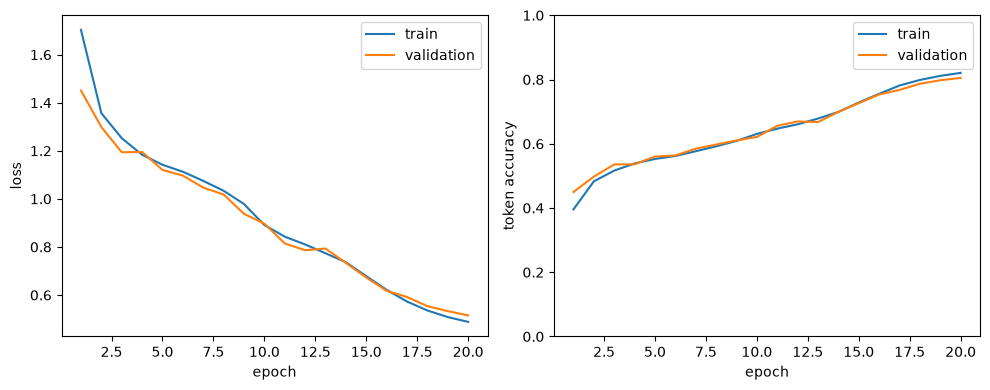

In [9]:
epochs = range(1, len(history.train) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [metrics.loss for metrics in history.train], label="train")
plt.plot(epochs, [metrics.loss for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [metrics.accuracy for metrics in history.train], label="train")
plt.plot(epochs, [metrics.accuracy for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("token accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

In [10]:
final_train = history.train[-1]
final_validation = history.validation[-1]

print(
    f"final train loss={final_train.loss:.4f}, "
    f"train acc={final_train.accuracy:.3f}, "
    f"val loss={final_validation.loss:.4f}, "
    f"val acc={final_validation.accuracy:.3f}"
)
print(f"optimizer steps: {int(optimizer.step[...])}")

final train loss=0.4882, train acc=0.821, val loss=0.5152, val acc=0.805
optimizer steps: 10240
